In [197]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [198]:
df = pd.read_csv("heart_2020_cleaned.csv")

In [199]:
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [200]:
df.shape

(319795, 18)

In [201]:
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

In [202]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [203]:
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [204]:
missing = df.isnull().sum()
missing_prcnt = (missing/len(df))*100
missing_df = pd.DataFrame({"Missing Values": missing, "Percentage":missing_prcnt})
missing_df = missing_df[missing_df["Missing Values"]>0]
missing_df

,Missing Values,Percentage


In [205]:
df.duplicated().sum()

np.int64(18078)

In [206]:
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [207]:
df = df.drop(columns = [c for c in df.columns if c.endswith(" outliers")])
df.columns

Index(['HeartDisease', 'BMI', 'Smoking', 'AlcoholDrinking', 'Stroke',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Sex', 'AgeCategory',
       'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'SkinCancer'],
      dtype='object')

**Data overview & takeaways**
The dataset has 319,795 rows and 18 columns - 1 target `HeartDisease` and 17 predictors
**4 numeric features** : `BMI`, `PhysicalHealth`, `MentalHealth`, `SleepTime`. The rest are categorical/binary.

**Missing values & duplicates**
There are *no missing values*, however, those values are self-reported survey responses rather than clinical measurements.
18,078 duplicate rows were found which is expected with a few numerical features, those duplicated rows were removed reducing the rows to 301,717.

### EDA

In [208]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,301717.000000,301717.000000,301717.000000,301717.000000
mean,28.441970,3.572298,4.121475,7.084559
std,6.468134,8.140656,8.128288,1.467122
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.410000,0.000000,0.000000,7.000000
75%,31.650000,2.000000,4.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


#### Descriptive statistics takeaways

**BMI:** mean = 28.3 / std=6.35 *in the overweight range*. The max = 94.8 is an extreme value *outlier*.
**PhysicalHealth / MentalHealth:** strongly 0 inflated which causes a right skew
**SleepTime:** arounf 7 hours which is fairly centered, but the max being 24 hours is an indicator of self-reported data.

In [209]:
categ_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist() 
low_cardinality_numeric = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() <= 5]

categ_cols = categ_cols + low_cardinality_numeric

In [210]:
print("Number of unique values per column:")
for col in categ_cols:
    print(col, df[col].nunique())

Number of unique values per column:
HeartDisease 2
Smoking 2
AlcoholDrinking 2
Stroke 2
DiffWalking 2
Sex 2
AgeCategory 13
Race 6
Diabetic 4
PhysicalActivity 2
GenHealth 5
Asthma 2
KidneyDisease 2
SkinCancer 2


In [211]:
for col in categ_cols:
    print(df[col].value_counts(normalize=True)*100)

HeartDisease
No     90.964712
Yes     9.035288
Name: proportion, dtype: float64
Smoking
No     57.773344
Yes    42.226656
Name: proportion, dtype: float64
AlcoholDrinking
No     92.847271
Yes     7.152729
Name: proportion, dtype: float64
Stroke
No     96.001551
Yes     3.998449
Name: proportion, dtype: float64
DiffWalking
No     85.299138
Yes    14.700862
Name: proportion, dtype: float64
Sex
Female    52.920783
Male      47.079217
Name: proportion, dtype: float64
AgeCategory
65-69          10.496591
60-64          10.347113
70-74           9.702138
55-59           9.150959
50-54           7.866975
80 or older     7.739703
75-79           6.865042
45-49           6.800412
18-24           6.628065
40-44           6.574704
35-39           6.471627
30-34           5.950278
25-29           5.406391
Name: proportion, dtype: float64
Race
White                             75.476026
Hispanic                           8.984247
Black                              7.560065
Other                    

#### Categorical Distribution takeaways

- **Target imbalance:** `HeartDisease` is extrmely imbalanced with only 8.5% of the records having heart diseas. Class weighting/resampling will be required for medl training.
- Other risk factors are also imbalanced; ` Stroke`, `KidneyDisease`, `AlcholholDrinking`.
- `Race` is heavily skewed towards *White* with all othe rgroups forming minorities.
- `AgeCategory` is evenly distributed.

In [212]:
numeric_cols = [col for col in df.select_dtypes(include=['int64','float64']).columns 
                           if df[col].nunique() > 5]
numeric_cols

['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']

In [213]:
print("Numeric data skew:")
skew = df[numeric_cols].skew().sort_values(ascending=False)
skew

Numeric data skew:


PhysicalHealth    2.501000
MentalHealth      2.237470
BMI               1.297737
SleepTime         0.697224
dtype: float64

#### Skewness takeaways

- `PhysicalHealth` and `MentalHealth` are strongly right skewed.
- `BMI` is moderstly skewed
- `SleepTime` is close to symmetric

#### Univariate Analysis

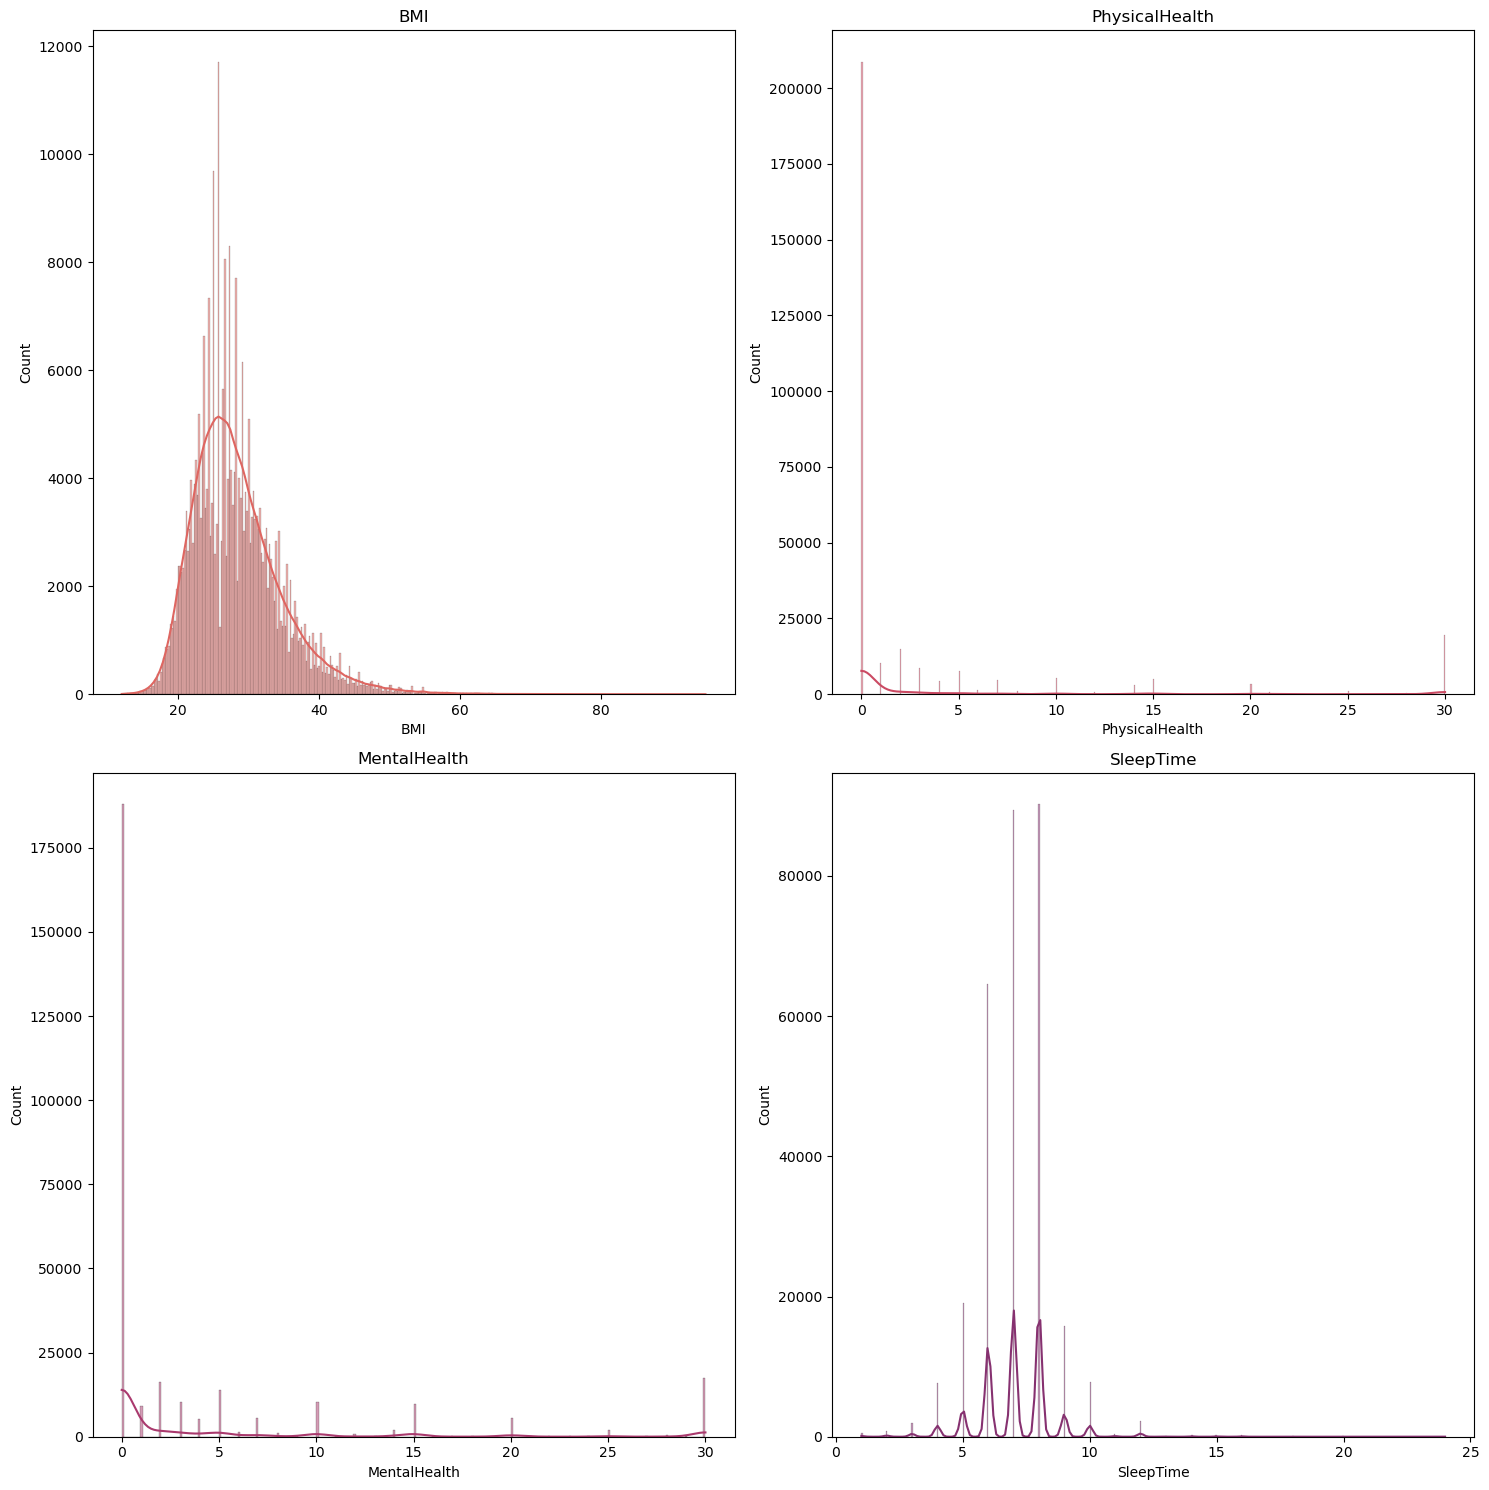

In [214]:
colors = ["#de6661", "#cb4a63", "#aa3a6e", "#863170"]
col = ["BMI", "PhysicalHealth",	"MentalHealth",	"SleepTime"]

fig , axes = plt.subplots(2,2, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(col):
    sns.histplot(df[col], kde= True, ax=axes[i], color=colors[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

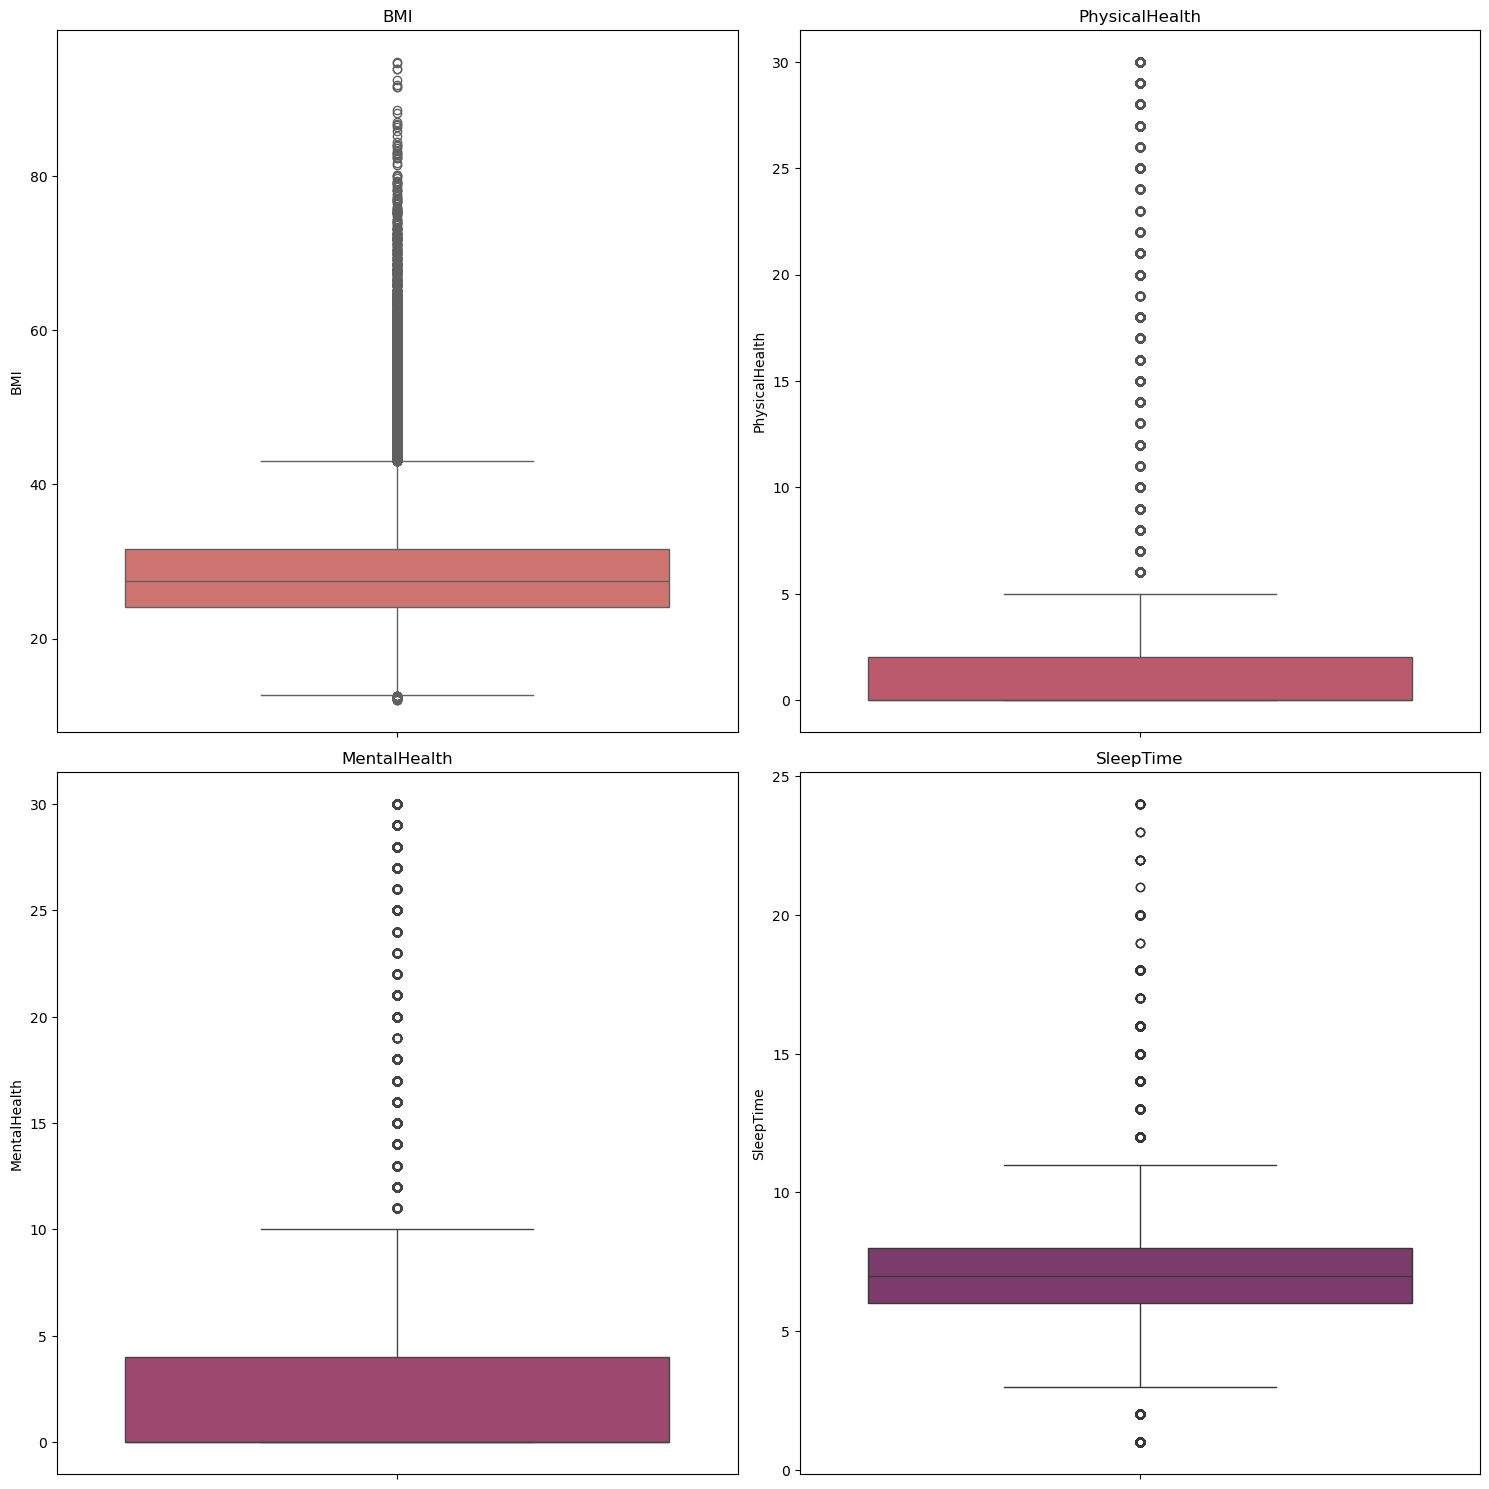

In [215]:
colors = ["#de6661", "#cb4a63", "#aa3a6e", "#863170"]
col = ["BMI", "PhysicalHealth",	"MentalHealth",	"SleepTime"]

fig , axes = plt.subplots(2,2, figsize=(15,15))
axes = axes.flatten()
for i, col in enumerate(col):
    sns.boxplot(df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

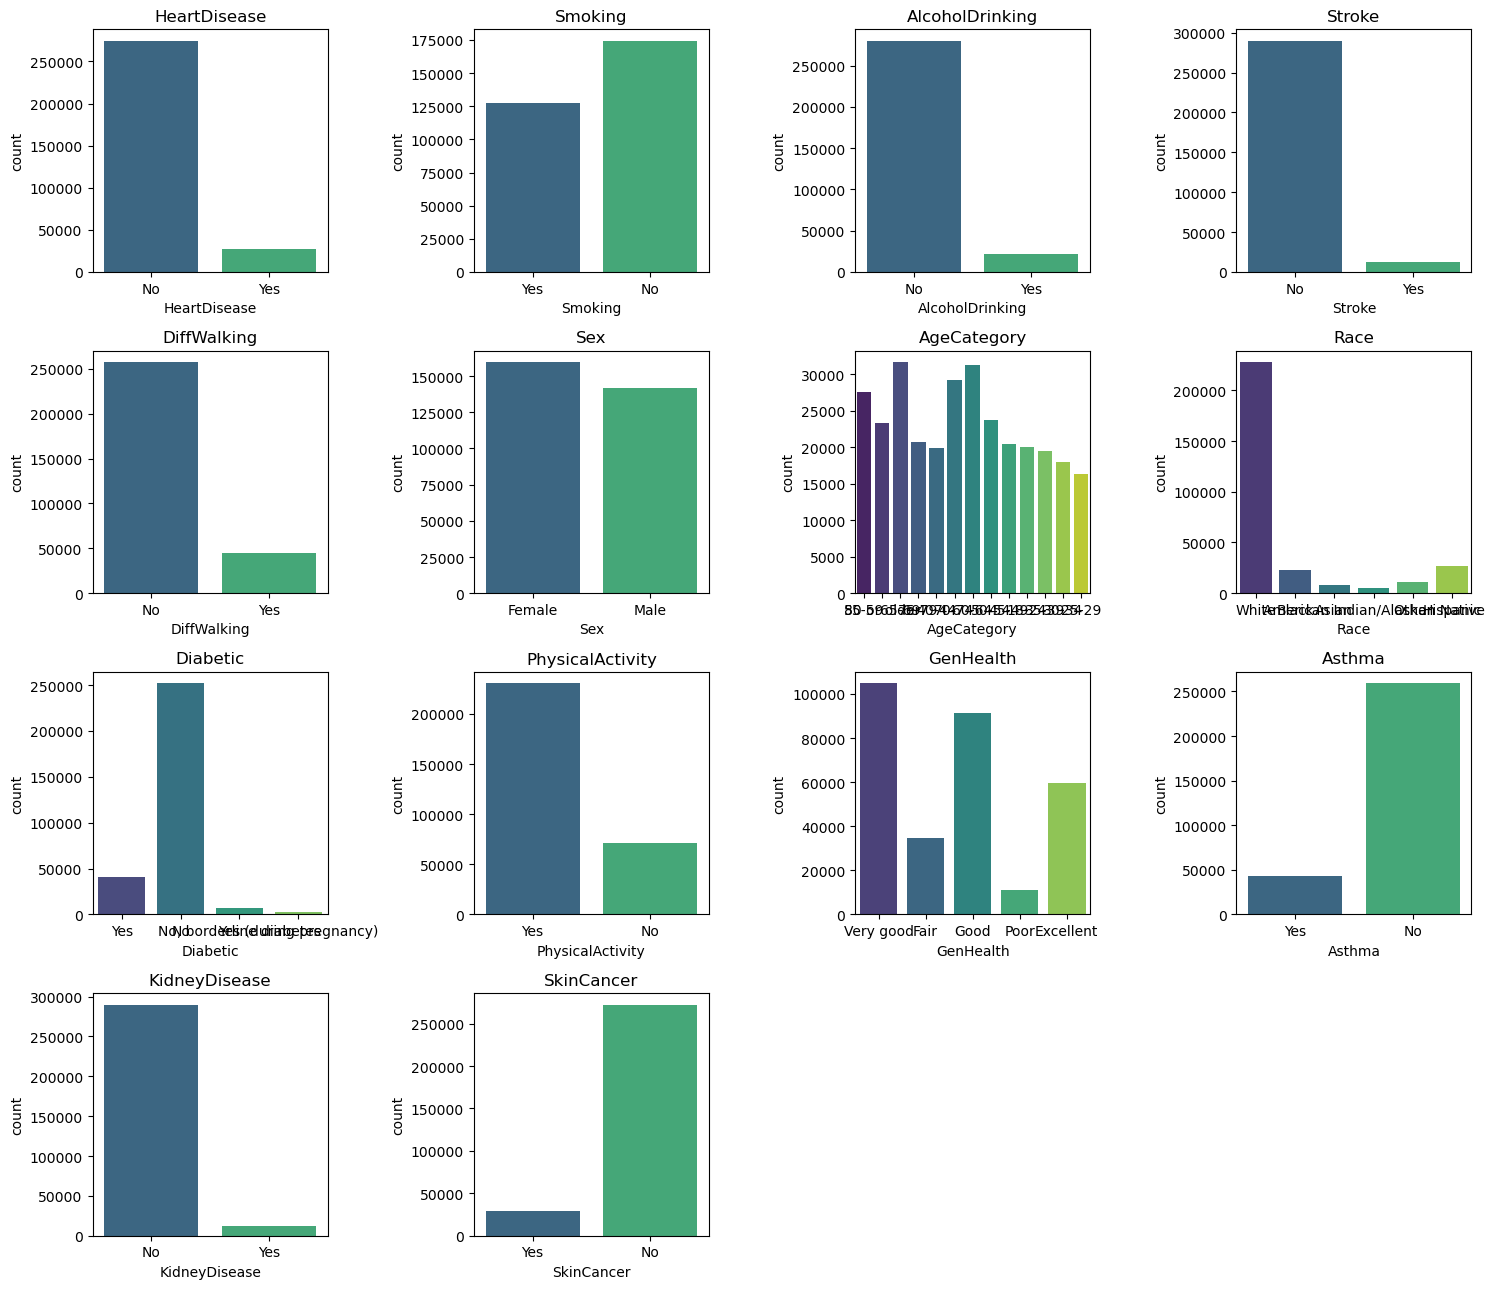

In [216]:
fig , axes = plt.subplots(4,4, figsize=(15,13))
axes = axes.flatten()

for i, col in enumerate(categ_cols):
    sns.countplot(x=df[col], hue=df[col], ax=axes[i], palette='viridis')
    axes[i].set_title(col)

axes[-1].axis('off')
axes[-2].axis('off')
plt.tight_layout()
plt.show()

In [217]:
outlier_flages = pd.DataFrame(index=df.index)
outlier_counts = {}

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    up = q3 + 1.5 * iqr
    df[f"{col} outliers"] = (df[col].values < low) | (df[col].values > up)

df.filter(like=" outliers").sum()

BMI outliers                8905
PhysicalHealth outliers    47136
MentalHealth outliers      39713
SleepTime outliers          4542
dtype: int64

#### Univariate Analysis wrap-up

- The huge outlier counts for `PhysicalHealth` and `MentalHeakth` are high but valide outliers, those numbers show real meaningful data and will be left as they are for now.
- `SleepTime` outliers are the smallest group and are likely to include erros (e.g 24 hrs)

#### Bivariate Analysis

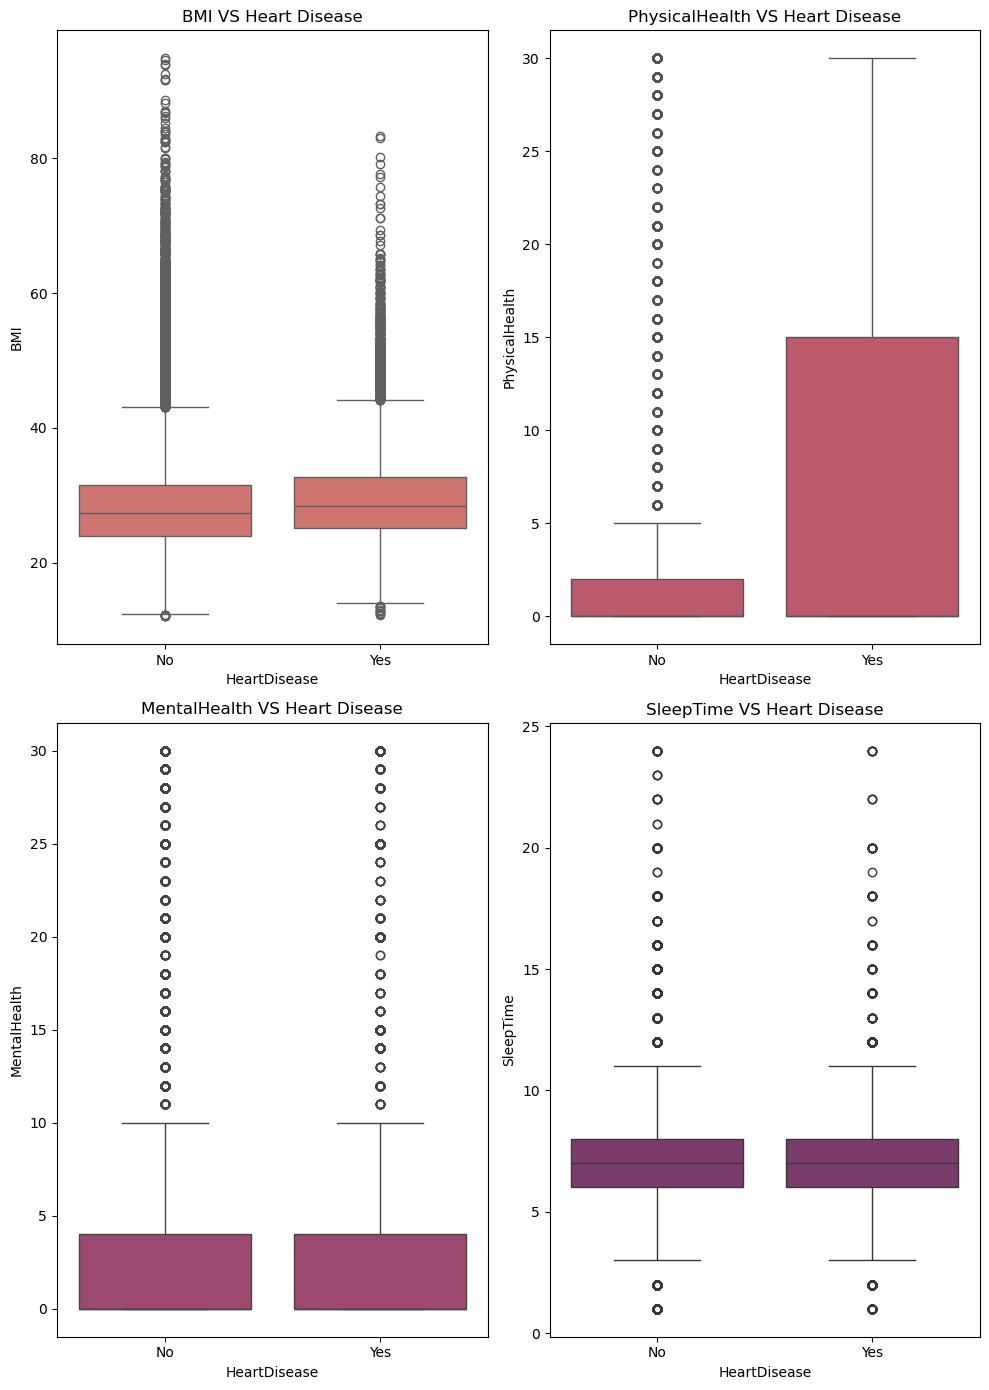

In [218]:
fig , axes = plt.subplots(2,2, figsize=(10,14))
axes = axes.flatten()
colors = ["#de6661", "#cb4a63", "#aa3a6e", "#863170"]

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df["HeartDisease"], y=df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(f"{col} VS Heart Disease")

plt.tight_layout()
plt.show()

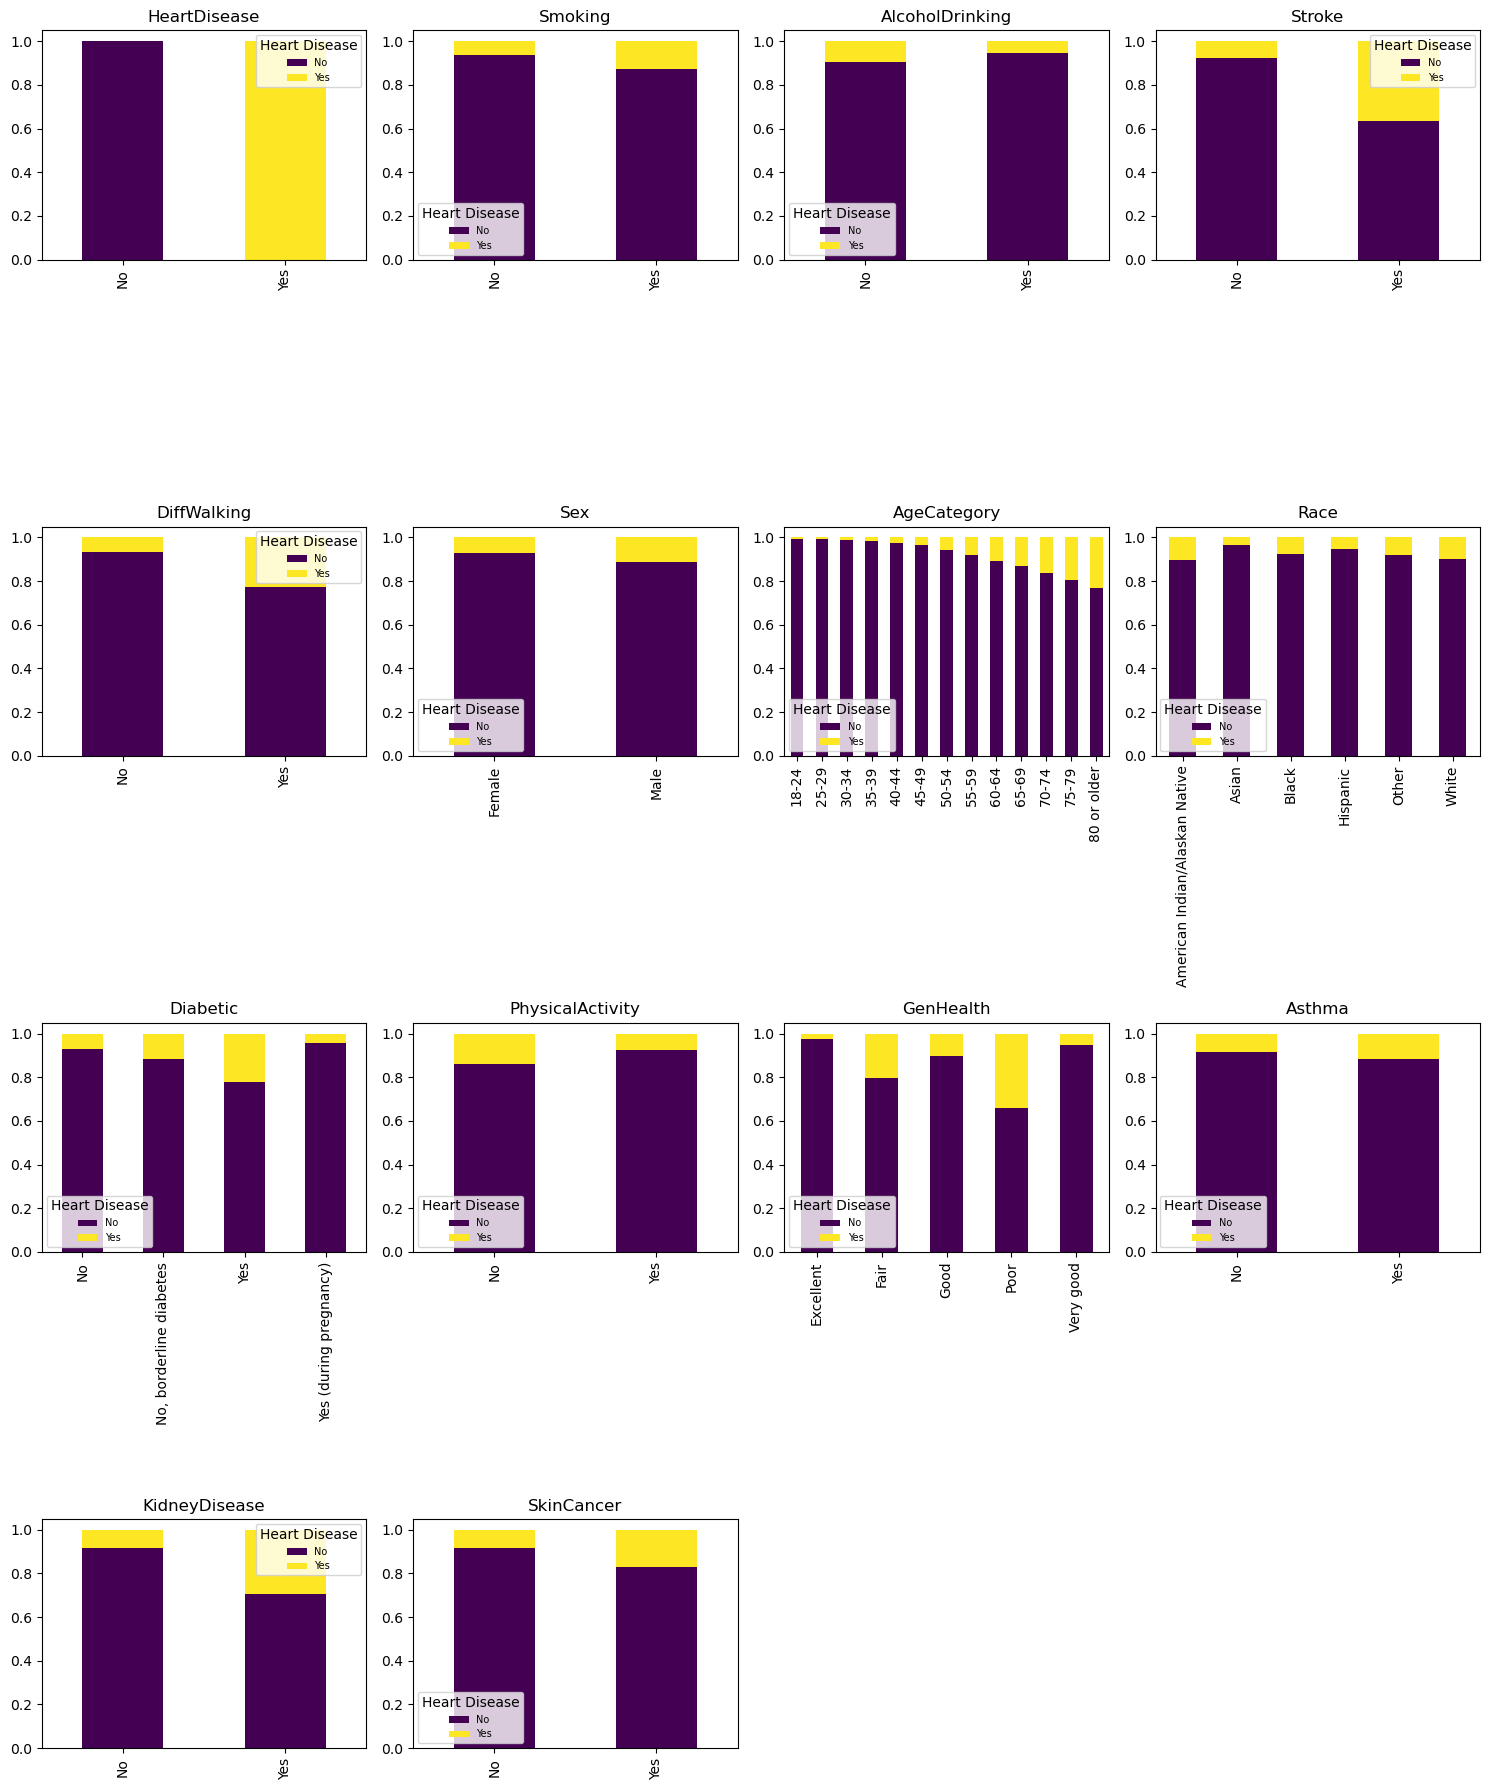

In [219]:
fig , axes = plt.subplots(4,4, figsize=(15,18))
axes = axes.flatten()
for i, col in enumerate(categ_cols):
    pd.crosstab(df[col], df["HeartDisease"], normalize='index').plot(kind='bar', stacked='True', ax=axes[i], colormap='viridis')
    axes[i].set_title(col)
    axes[i].legend(title="Heart Disease", fontsize=7)
    axes[i].set_xlabel("")

axes[-1].axis('off')
axes[-2].axis('off')
plt.tight_layout()
plt.show()

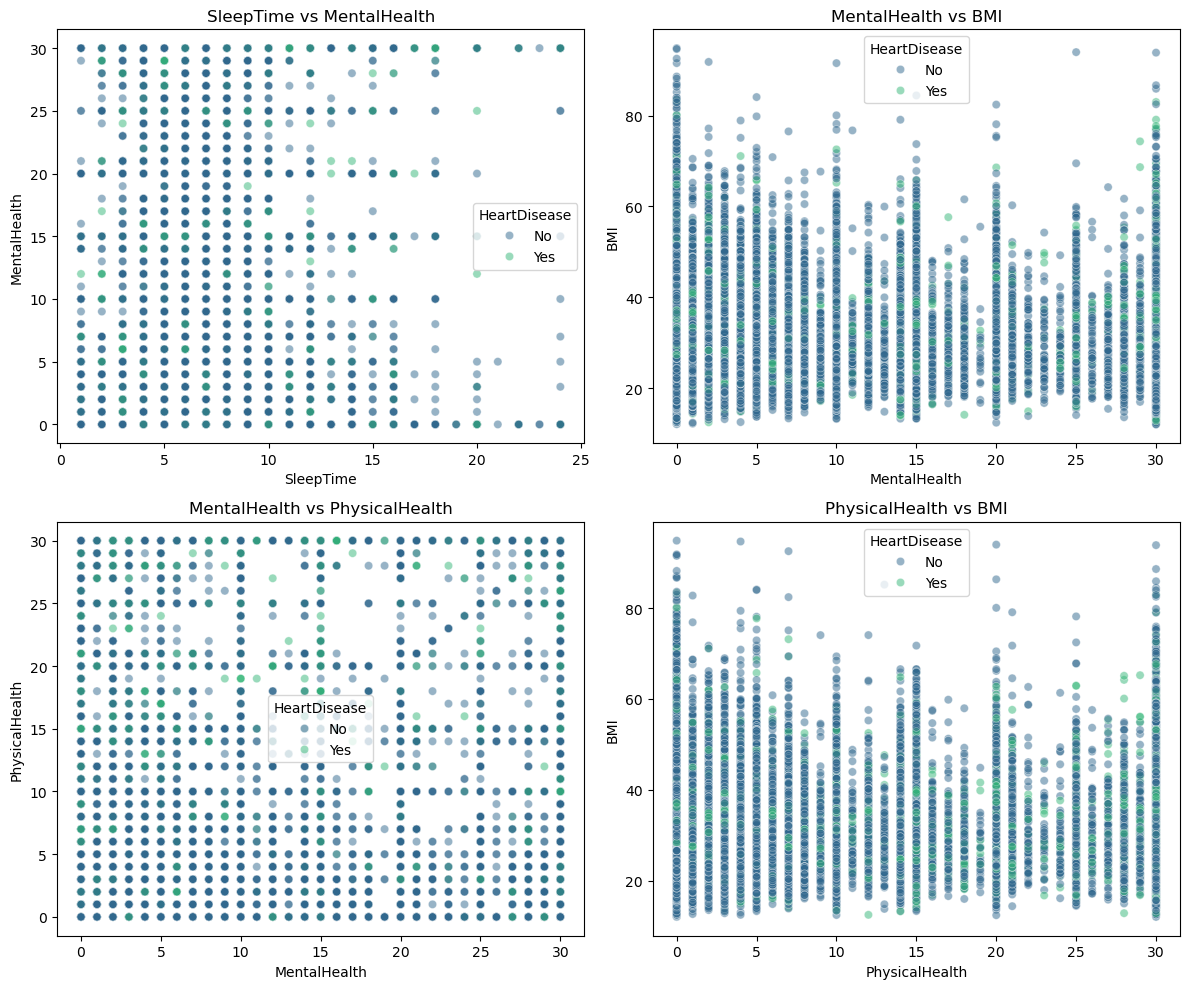

In [220]:
pairs = [
    ("SleepTime", "MentalHealth"),
    ("MentalHealth", "BMI"), 
    ("MentalHealth", "PhysicalHealth"),
    ("PhysicalHealth", "BMI")
]
fig, axes = plt.subplots(2,2, figsize=(12,10))
axes = axes.flatten()

for i,(x_col, y_col) in enumerate (pairs):
    sns.scatterplot(data = df, x=x_col, y=y_col, hue="HeartDisease", palette='viridis', alpha=0.5, ax=axes[i])
    axes[i].set_title(f"{x_col} vs {y_col}")

plt.tight_layout()
plt.show()

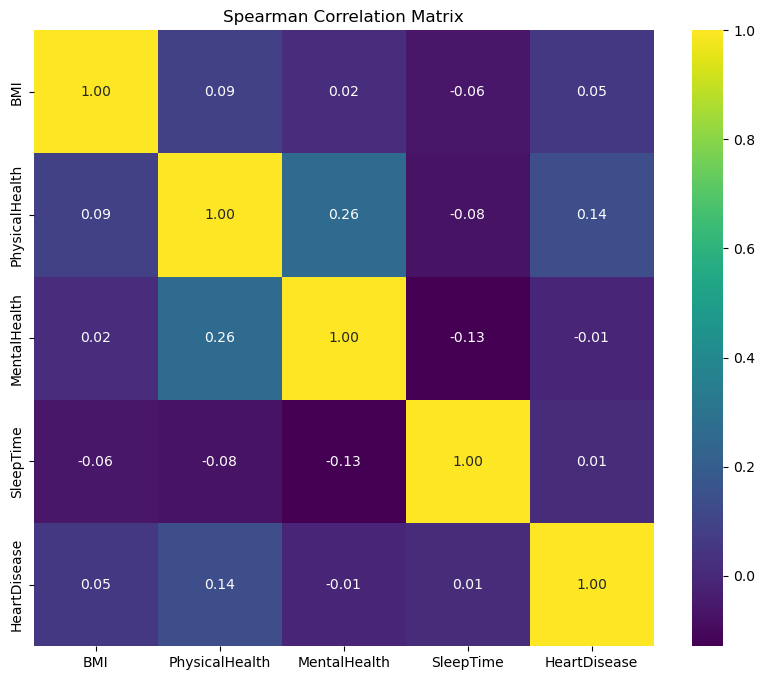

In [221]:
# Target Encoding
df["HeartDisease"] = df["HeartDisease"].map({"Yes":1, "No":0})


corr_cols= numeric_cols + ["HeartDisease"]
corr = df[corr_cols].corr(method="spearman")
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="viridis", annot=True, fmt=".2f")
plt.title("Spearman Correlation Matrix")
plt.show()

#### Bivariate Analysis & EDA takeaways

- The stacked bar charts against `HearatDisease` show the clearestsignal in categorical featues; `AgeCatgory` shows a strong increase in heart disease rate with age, `GenHealth` shows a hiegher rate for *Poor*, `Stroke` `DiffWalking` `KidneyDisease` `Diabetic` show visibly elevated rates in their *Yes* groups .

- The Spearman correlation matrix shows numeric features are *weakly correlated with heart disease*

- `PhysicalHealth` and `MentalHealth` have a mild positive correlation with each other

- Overall, categoriacl features look like the primary drivers, the target is imbalanced and these observations will influence the feature engineeering and modelling decisions later.

### Data Cleaning

In [222]:
df = df.drop(columns = [c for c in df.columns if c.endswith(" outliers")])
df.shape

(301717, 18)

In [223]:
df["BMI"] = df["BMI"].clip(upper=70)
df["SleepTime"] = df["SleepTime"].clip(upper=16)
df.shape

(301717, 18)

### Train/Test Splitting

In [224]:
#to avoid data leakage, the dataset will be split before any further transformations
from sklearn.model_selection import train_test_split

x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=42)
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(HeartDisease
 0    0.909646
 1    0.090354
 Name: proportion, dtype: float64,
 HeartDisease
 0    0.909651
 1    0.090349
 Name: proportion, dtype: float64)

In [225]:
# encoding categoricals
#AgeCategory & GenHealth will be explicitly encoded to preserve their order
# other categorical features that do not require oreder will be one-hot/label encoded
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

age_order = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
genhealth_order = ['Poor', 'Fair', 'Good', 'Very good', 'Excellent']

    
ordinal_columns = ["AgeCategory", "GenHealth"]
ordinal_categories = [age_order, genhealth_order]

binary_columns = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking", "Sex", "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]
nominal_columns = ["Race", "Diabetic"]


In [226]:
# ordinal encoding
ord_enc = OrdinalEncoder(categories=ordinal_categories)
x_train[ordinal_columns] = ord_enc.fit_transform(x_train[ordinal_columns])
x_test[ordinal_columns] = ord_enc.transform(x_test[ordinal_columns])

In [227]:
#yes/no -> 1/0
for col in binary_columns:
    x_train[col] = x_train[col].map({"Yes":1, "No":0})
    x_test[col] = x_test[col].map({"Yes":1, "No":0})

In [228]:
# one-hot encoding nominal columns
x_train = pd.get_dummies(x_train, columns=nominal_columns, drop_first=False)
x_test = pd.get_dummies(x_test, columns=nominal_columns, drop_first=False)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

### Feature Engineering

In [229]:
# The Evaluation of physical and mental health done by the model on a scale from 0 to 30 is draining for the model,
# and therefore the scale will be turned into 3 buckets to capture the pattern better.
def bin_health_days(series):
    return pd.cut(series, bins=[-1, 0, 13,30], labels =["none", "some", "frequent"])

for df_ in [x_train, x_test]:
    if "PhysicalHealth" in df_.columns:
        df_["PhysicalHealth_bin"] = bin_health_days(df_["PhysicalHealth"])
    if "MentalHealth" in df_.columns:
        df_["MentalHealth_bin"] = bin_health_days(df_["MentalHealth"])

bin_cols= [c for c in ["PhysicalHealth_bin", "MentalHealth_bin"] if c in x_train.columns]
#one-hot encoding the new columns
x_train = pd.get_dummies(x_train, columns=bin_cols)
x_test = pd.get_dummies(x_test, columns=bin_cols)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)
                        

In [230]:
# a combined risk factor column that consists of Stroke, DiffWalking, KidneyDisease, Dibetic, Smoking

risk_columns = ["Stroke", "DiffWalking", "KidneyDisease", "Dibetic", "Smoking"]
risk_columns = [c for c in risk_columns if c in x_train.columns]

x_train["RiskFactorCount"] = x_train[risk_columns].sum(axis=1)
x_test["RiskFactorCount"] = x_test[risk_columns].sum(axis=1)

In [233]:
x_train.shape


(241373, 32)

In [234]:
# removing redundant columns

x_train = x_train.drop(columns=["PhysicalHealth", "MentalHealth"])
x_test = x_test.drop(columns=["PhysicalHealth", "MentalHealth"])

In [235]:
x_train.shape

(241373, 30)

In [239]:
# scaling numeric features
from sklearn.preprocessing import StandardScaler

numeric_to_scale = ["BMI", "SleepTime", "RiskFactorCount" ,"AgeCategory", "GenHealth"]
scaler = StandardScaler()
x_train[numeric_to_scale] = scaler.fit_transform(x_train[numeric_to_scale])
x_test[numeric_to_scale] = scaler.transform(x_test[numeric_to_scale])

### The baseline Model - Logistic Regression

In [244]:
x_train.isnull().sum()[x_train.isnull().sum() > 0]

Sex    241373
dtype: int64

In [241]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy="most_frequent").fit(x_train, y_train)
dummy_pred = dummy.predict(x_test)
print("Dummy ROC-AUC:", roc_auc_score(y_test, dummy.predict_proba(x_test)[:,1]))


lreg = LogisticRegression(max_iter=1000, class_weight="balanced")
lreg.fit(x_train,y_train)
lreg_prob = lreg.predict_proba(x_test)[:,1]
lreg_pred = lreg.predict(x_test)

print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, lreg_prob))
print("Logistic Regression PR-AUC:",average_precision_score(y_test, lreg_prob))
print(classification_report(y_test, lreg_pred))

Dummy ROC-AUC: 0.5


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
## the baseline code is incomplete and will be fixed tomorrow